# Appendix A6: Stimulus filter (HEKA)
**Appendix A provides extra background for path clamp electronics.**

In [Appendix A4](./4-bessel-filters.ipynb) and [Appendix A5](./5-bessel-filter-odes.ipynb) we looked at the 2-pole Bessel stimulus filter on HEKA amplifiers.
We saw it had two settings, labelled "20 µs" (default) and "2 µs", but that these numbers don't match up to the actual rise time.

In this notebook, we use the ODE equations of a 2-pole and 1-pole filter, and fit them to data measured in a model cell.

## Model cell recordings

First, we load "20us" and "2us" data.

In [1]:
import myokit
import matplotlib.pyplot as plt
import numpy as np

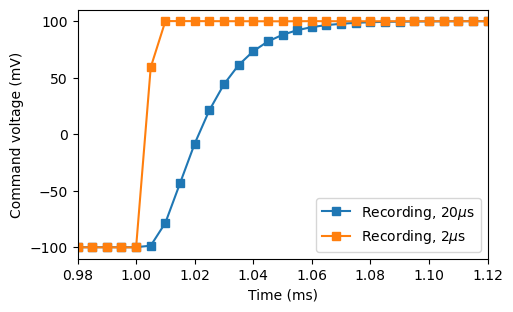

In [2]:
d0 = myokit.DataLog.load('./res/stimulus-filter.zip').npview()

fig = plt.figure(figsize=(5, 3))
fig.subplots_adjust(0.14, 0.15, 0.96, 0.98)
ax = fig.add_subplot()
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Command voltage (mV)')
ax.plot(d0.time(), d0['v20us'], 's-', label=r'Recording, 20$\mu$s')
ax.plot(d0.time(), d0['v2us'], 's-', label=r'Recording, 2$\mu$s')
ax.legend()
ax.set_xlim(0.98, 1.12)
plt.show()

## Guessed rise times

Next, we fit each by postulating rise times of 40 and 4 $\mu$s.

In [3]:
m = myokit.parse_model("""
[[model]]
filter.y1 = 0
filter.y2 = 0
filter.y3 = 0

[filter]
pace = 0 bind pace
time = 0 bind time
tr = 0.04 [ms] in [ms]
# Second-order
a2 = tr * 1.3616 / log(9)
    in [ms]
dot(y1) = 3 * (pace/a2^2 - y2/a2^2 - y1/a2)
dot(y2) = y1
# First-order
a1 = tr / log(9)
    in [ms]
dot(y3) = (pace - y3) / a1
""")

p = myokit.Protocol()
p.add_step(level=-100, duration=1)
p.add_step(level=100, duration=10)

s = myokit.Simulation(m, p)
s.pre(1)
d1 = s.run(2, log_interval=1e-3).npview()

s.reset()
s.set_constant('filter.tr', 0.004)
s.pre(1)
d2 = s.run(2, log_interval=1e-3).npview()

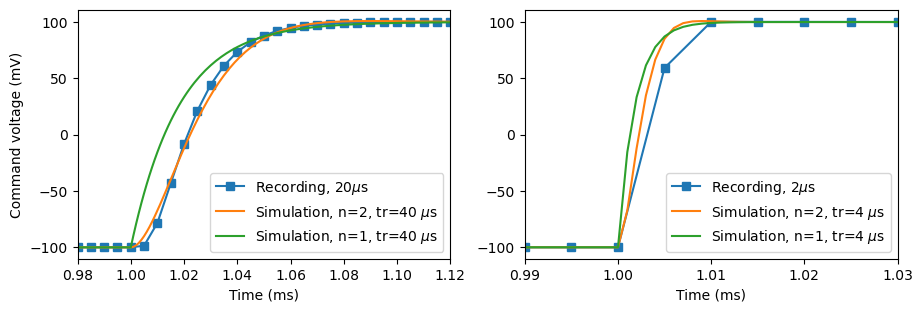

In [4]:
fig = plt.figure(figsize=(10, 3))
fig.subplots_adjust(0.14, 0.15, 0.96, 0.98)

ax = fig.add_subplot(1, 2, 1)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Command voltage (mV)')
ax.plot(d0.time(), d0['v20us'], 's-', label=r'Recording, 20$\mu$s')
ax.plot(d1.time(), d1['filter.y2'], label=r'Simulation, n=2, tr=40 $\mu$s')
ax.plot(d1.time(), d1['filter.y3'], label=r'Simulation, n=1, tr=40 $\mu$s')
ax.legend()
ax.set_xlim(0.98, 1.12)

ax = fig.add_subplot(1, 2, 2)
ax.set_xlabel('Time (ms)')
ax.plot(d0.time(), d0['v2us'], 's-', label=r'Recording, 2$\mu$s')
ax.plot(d1.time(), d2['filter.y2'], label=r'Simulation, n=2, tr=4 $\mu$s')
ax.plot(d1.time(), d2['filter.y3'], label=r'Simulation, n=1, tr=4 $\mu$s')
ax.legend()
ax.set_xlim(0.99, 1.03)
plt.show()

This shows that, as a first approximation we can use rise times of 40 and 4 $\mu$s for the stimulus filter.

The equivalent 1-pole time constants are:

In [5]:
0.04 / np.log(9)

np.float64(0.018204784532536746)

and

In [6]:
0.004 / np.log(9)

np.float64(0.0018204784532536748)

## Fitted rise times

Next, we use `fmin` to find the rise times that give the best fits.

### Two-pole fits

In [7]:
from scipy.optimize import fmin

def error(tr):
    s.reset()
    s.set_constant('filter.tr', tr[0])
    d = s.run(2, log_times=d0.time())
    return np.sum((d0['v20us'] - d['filter.y2'])**2)

tr2slow = fmin(error, 0.04, disp=False)[0]
print(f'Rise time {tr2slow} ms')

s.set_constant('filter.tr', tr2slow)
s.reset()
s.pre(1)
d1 = s.run(2, log_interval=1e-3).npview()

Rise time 0.03838024902343749 ms


In [8]:
def error(tr):
    s.reset()
    s.set_constant('filter.tr', tr[0])
    d = s.run(2, log_times=d0.time())
    return np.sum((d0['v2us'] - d['filter.y2'])**2)

tr2fast = fmin(error, 0.004, disp=False)[0]
print(f'Rise time {tr2fast} ms')

s.set_constant('filter.tr', tr2fast)
s.reset()
s.pre(1)
d2 = s.run(2, log_interval=1e-3).npview()

Rise time 0.005369531250000004 ms


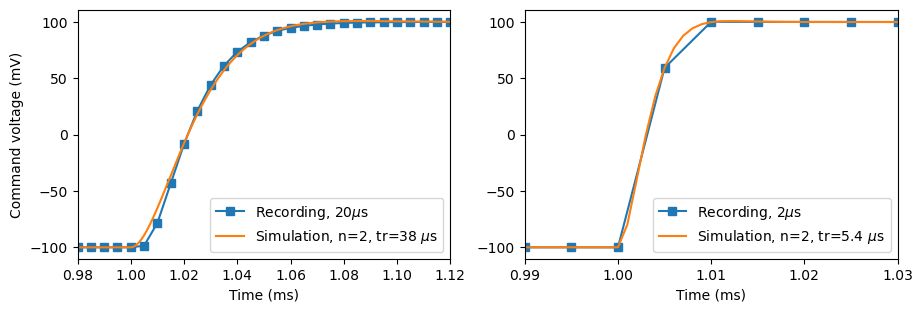

In [9]:
fig = plt.figure(figsize=(10, 3))
fig.subplots_adjust(0.14, 0.15, 0.96, 0.98)

ax = fig.add_subplot(1, 2, 1)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Command voltage (mV)')
ax.plot(d0.time(), d0['v20us'], 's-', label=r'Recording, 20$\mu$s')
ax.plot(d1.time(), d1['filter.y2'], label=rf'Simulation, n=2, tr={1e3*tr2slow:.0f} $\mu$s')
ax.legend()
ax.set_xlim(0.98, 1.12)

ax = fig.add_subplot(1, 2, 2)
ax.set_xlabel('Time (ms)')
ax.plot(d0.time(), d0['v2us'], 's-', label=r'Recording, 2$\mu$s')
ax.plot(d1.time(), d2['filter.y2'], label=rf'Simulation, n=2, tr={1e3*tr2fast:.1f} $\mu$s')
ax.legend()
ax.set_xlim(0.99, 1.03)
plt.show()

### One-pole fits

In [10]:
def error(tr):
    s.reset()
    s.set_constant('filter.tr', tr[0])
    d = s.run(2, log_times=d0.time())
    return np.sum((d0['v20us'] - d['filter.y3'])**2)

tr1slow = fmin(error, 0.04, disp=False)[0]
print(f'Rise time {tr1slow} ms')
print(f'Time constant {tr1slow / np.log(9)} ms')

s.set_constant('filter.tr', tr1slow)
s.reset()
s.pre(1)
d3 = s.run(2, log_interval=1e-3).npview()

Rise time 0.05562500000000001 ms
Time constant 0.025316028490558917 ms


In [11]:
def error(tr):
    s.reset()
    s.set_constant('filter.tr', tr[0])
    d = s.run(2, log_times=d0.time())
    return np.sum((d0['v2us'] - d['filter.y3'])**2)

tr1fast = fmin(error, 0.004, disp=False)[0]
print(f'Rise time {tr1fast} ms')
print(f'Time constant {tr1fast / np.log(9)} ms')

s.set_constant('filter.tr', tr1fast)
s.reset()
s.pre(1)
d4 = s.run(2, log_interval=1e-3).npview()

Rise time 0.006590625000000008 ms
Time constant 0.0029995227014937534 ms


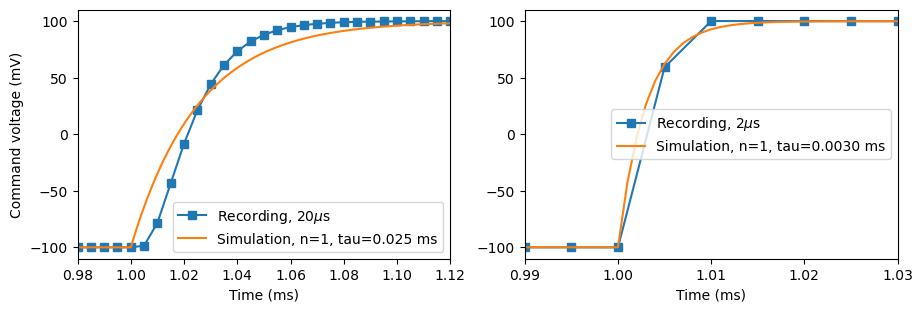

In [12]:
fig = plt.figure(figsize=(10, 3))
fig.subplots_adjust(0.14, 0.15, 0.96, 0.98)

ax = fig.add_subplot(1, 2, 1)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Command voltage (mV)')
ax.plot(d0.time(), d0['v20us'], 's-', label=r'Recording, 20$\mu$s')
ax.plot(d3.time(), d3['filter.y3'], label=rf'Simulation, n=1, tau={tr1slow / np.log(9):.3f} ms')
ax.legend()
ax.set_xlim(0.98, 1.12)

ax = fig.add_subplot(1, 2, 2)
ax.set_xlabel('Time (ms)')
ax.plot(d0.time(), d0['v2us'], 's-', label=r'Recording, 2$\mu$s')
ax.plot(d4.time(), d4['filter.y3'], label=rf'Simulation, n=1, tau={tr1fast / np.log(9):.4f} ms')
ax.legend()
ax.set_xlim(0.99, 1.03)
plt.show()

So we can get reasonable approximations with a 1-pole filter with a tau of 25 or 3 $\mu$s.